<a href="https://www.kaggle.com/code/sonawanelalitsunil/youtube-s-most-popular-songs-of-2025-eda-90?scriptVersionId=266704790" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from wordcloud import WordCloud
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/most-popular-songs-on-youtube-2025/youtube-top-100-songs-2025.csv


## YouTube’s Most Popular Songs of 2025

## Description:
Dive into the rhythm of 2025 with a look at YouTube’s most popular songs of the year. This list highlights the tracks that ruled global playlists, broke streaming records, and defined online music culture. From viral hits and trending remixes to powerful collaborations and chart-topping anthems, explore how artists captured millions of hearts and billions of views worldwide.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/most-popular-songs-on-youtube-2025/youtube-top-100-songs-2025.csv")

In [3]:
df.head()

,title,fulltitle,description,view_count,categories,tags,duration,duration_string,live_status,thumbnail,channel,channel_url,channel_follower_count
0,ROSÉ & Bruno Mars - APT. (Official Music Video),ROSÉ & Bruno Mars - APT. (Official Music Video),ROSÉ & Bruno Mars - APT.\nDownload/stream: ht...,2009014557,Music,YG Entertainment;YG;와이지;K-pop;BLACKPINK;블랙핑크;블...,173,2:53,False,https://i.ytimg.com/vi_webp/ekr2nIex040/maxres...,ROSÉ,https://www.youtube.com/channel/UCBo1hnzxV9rz3...,19200000
1,"Lady Gaga, Bruno Mars - Die With A Smile (Offi...","Lady Gaga, Bruno Mars - Die With A Smile (Offi...",MAYHEM OUT NOW\nhttp://ladygaga.com \n \nListe...,1324833300,Music,Lady Gaga;Bruno Mars;Interscope;Pop,252,4:12,False,https://i.ytimg.com/vi/kPa7bsKwL-c/maxresdefau...,Lady Gaga,https://www.youtube.com/channel/UC07Kxew-cMIay...,29600000
2,Reneé Rapp - Leave Me Alone (Official Music Vi...,Reneé Rapp - Leave Me Alone (Official Music Vi...,"Listen to “BITE ME”, the new album from Reneé ...",2536628,Music,Reneé Rapp;Interscope Records;Pop,160,2:40,False,https://i.ytimg.com/vi/tiPWzFLiz4A/maxresdefau...,Reneé Rapp,https://www.youtube.com/channel/UCZy4ki_L4bzw9...,408000
3,Billie Eilish - BIRDS OF A FEATHER (Official M...,Billie Eilish - BIRDS OF A FEATHER (Official M...,Listen to HIT ME HARD AND SOFT: https://billie...,558329099,Music,Billie Eilish;Darkroom/Interscope Records;Alte...,231,3:51,False,https://i.ytimg.com/vi/V9PVRfjEBTI/maxresdefau...,Billie Eilish,https://www.youtube.com/channel/UCDGmojLIoWpXo...,56800000
4,Reneé Rapp - Mad (Official Music Video),Reneé Rapp - Mad (Official Music Video),"Listen to “BITE ME”, the new album from Reneé ...",2113548,Music,Reneé Rapp;Interscope Records;Pop,180,3:00,False,https://i.ytimg.com/vi/xkWQM3flsiY/maxresdefau...,Reneé Rapp,https://www.youtube.com/channel/UCZy4ki_L4bzw9...,408000


In [4]:
df.tail()

,title,fulltitle,description,view_count,categories,tags,duration,duration_string,live_status,thumbnail,channel,channel_url,channel_follower_count
95,Ariana Grande - twilight zone (Official Lyric ...,Ariana Grande - twilight zone (Official Lyric ...,The official “twilight zone” official lyric vi...,18245315,Music,Ariana Grande;Republic Records;Pop,202,3:22,False,https://i.ytimg.com/vi/x1XIJM6spaE/maxresdefau...,Ariana Grande,https://www.youtube.com/channel/UC0VOyT2OCBKdQ...,56400000
96,"Gracie Abrams - I Love You, I’m Sorry (Officia...","Gracie Abrams - I Love You, I’m Sorry (Officia...","Listen to the new album, The Secret of Us, out...",31456772,Music,"Gracie Abrams;Gracie Abrams, under exclusive l...",234,3:54,False,https://i.ytimg.com/vi/uxjhN_Donfw/maxresdefau...,Gracie Abrams,https://www.youtube.com/channel/UCVFRVXH1hRoWk...,1770000
97,HoodTrophy Bino ft. FCG Heem - Miami (Official...,HoodTrophy Bino ft. FCG Heem - Miami (Official...,HoodTrophy Bino and FCG Heem drop Miami. From...,66051,Music,NaN,197,3:17,False,https://i.ytimg.com/vi_webp/I-gmbHgeN1I/maxres...,HoodTrophy Bino,https://www.youtube.com/channel/UCsaZi3QZrZ5-s...,20300
98,Sean Paul x INNA - Let It Talk To Me,Sean Paul x INNA - Let It Talk To Me,Song Title: Sean Paul x INNA - Let It Talk To ...,16952860,Music,Sean Paul,155,2:35,False,https://i.ytimg.com/vi_webp/nkRyAVQdqAA/maxres...,Sean Paul,https://www.youtube.com/channel/UCkdc7gHpavxpg...,5200000
99,"Selena Gomez, benny blanco - How Does It Feel ...","Selena Gomez, benny blanco - How Does It Feel ...",Listen to the new album 'I Said I Love You Fir...,16971256,Music,Selena Gomez;benny blanco;SMG Music LLC Friend...,161,2:41,False,https://i.ytimg.com/vi/4LcNr0T2yAA/maxresdefau...,Selena Gomez,https://www.youtube.com/channel/UCjK8ORC71kwyj...,35500000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   title                   100 non-null    object
 1   fulltitle               100 non-null    object
 2   description             100 non-null    object
 3   view_count              100 non-null    int64 
 4   categories              100 non-null    object
 5   tags                    85 non-null     object
 6   duration                100 non-null    int64 
 7   duration_string         100 non-null    object
 8   live_status             100 non-null    bool  
 9   thumbnail               100 non-null    object
 10  channel                 100 non-null    object
 11  channel_url             100 non-null    object
 12  channel_follower_count  100 non-null    int64 
dtypes: bool(1), int64(3), object(9)
memory usage: 9.6+ KB


In [6]:
df.describe()

,view_count,duration,channel_follower_count
count,1.000000e+02,100.000000,1.000000e+02
mean,1.059103e+08,203.900000,1.612067e+07
std,2.491132e+08,44.260592,1.980038e+07
min,1.161000e+03,120.000000,1.000000e+00
25%,1.852702e+07,173.000000,6.132500e+05
50%,3.798224e+07,193.500000,6.320000e+06
75%,1.111073e+08,231.750000,2.760000e+07
max,2.009015e+09,354.000000,7.620000e+07


In [7]:
df.dtypes

title                     object
fulltitle                 object
description               object
view_count                 int64
categories                object
tags                      object
duration                   int64
duration_string           object
live_status                 bool
thumbnail                 object
channel                   object
channel_url               object
channel_follower_count     int64
dtype: object

In [8]:
df.shape

(100, 13)

In [9]:
df.isnull().sum()

title                      0
fulltitle                  0
description                0
view_count                 0
categories                 0
tags                      15
duration                   0
duration_string            0
live_status                0
thumbnail                  0
channel                    0
channel_url                0
channel_follower_count     0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df.nunique()

title                     100
fulltitle                 100
description               100
view_count                100
categories                  2
tags                       76
duration                   69
duration_string            69
live_status                 1
thumbnail                 100
channel                    65
channel_url                69
channel_follower_count     65
dtype: int64

In [12]:
df.describe().loc[['min', 'max', 'mean']]

,view_count,duration,channel_follower_count
min,1.161000e+03,120.0,1.00
max,2.009015e+09,354.0,76200000.00
mean,1.059103e+08,203.9,16120665.61


In [13]:
df.columns

Index(['title', 'fulltitle', 'description', 'view_count', 'categories', 'tags',
       'duration', 'duration_string', 'live_status', 'thumbnail', 'channel',
       'channel_url', 'channel_follower_count'],
      dtype='object')

## Data visualizations

In [14]:
sns.set(style="whitegrid")
plt.rcParams['axes.facecolor'] = '#E8F4FA'
plt.rcParams['figure.facecolor'] = '#E8F4FA'
plt.rcParams['axes.labelcolor'] = 'darkblue'
plt.rcParams['xtick.color'] = 'darkblue'
plt.rcParams['ytick.color'] = 'darkblue'

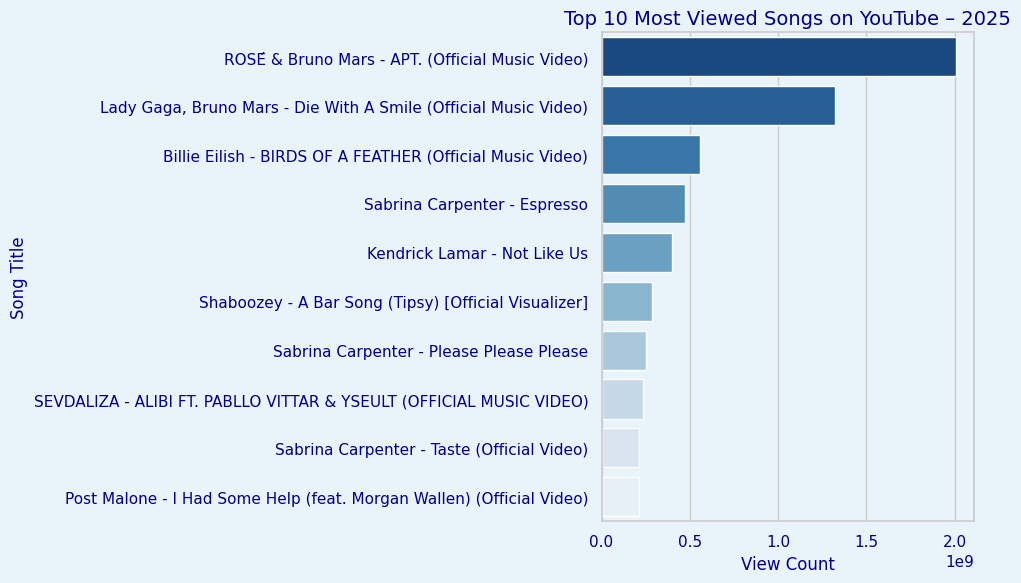

In [15]:
top_10_views = df.nlargest(10, 'view_count')
plt.figure(figsize=(10,6))
sns.barplot(x='view_count', y='title', data=top_10_views, palette='Blues_r')
plt.title("Top 10 Most Viewed Songs on YouTube – 2025", fontsize=14, color='darkblue')
plt.xlabel("View Count")
plt.ylabel("Song Title")
plt.tight_layout()
plt.show()

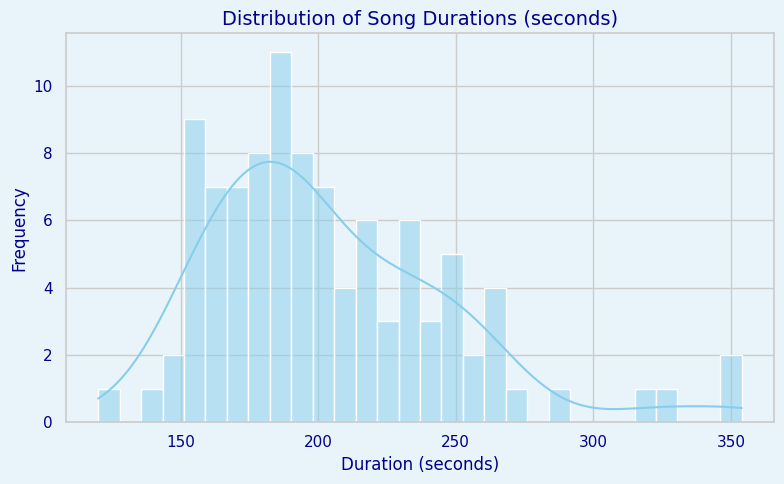

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df['duration'], bins=30, kde=True, color='skyblue')
plt.title("Distribution of Song Durations (seconds)", fontsize=14, color='darkblue')
plt.xlabel("Duration (seconds)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

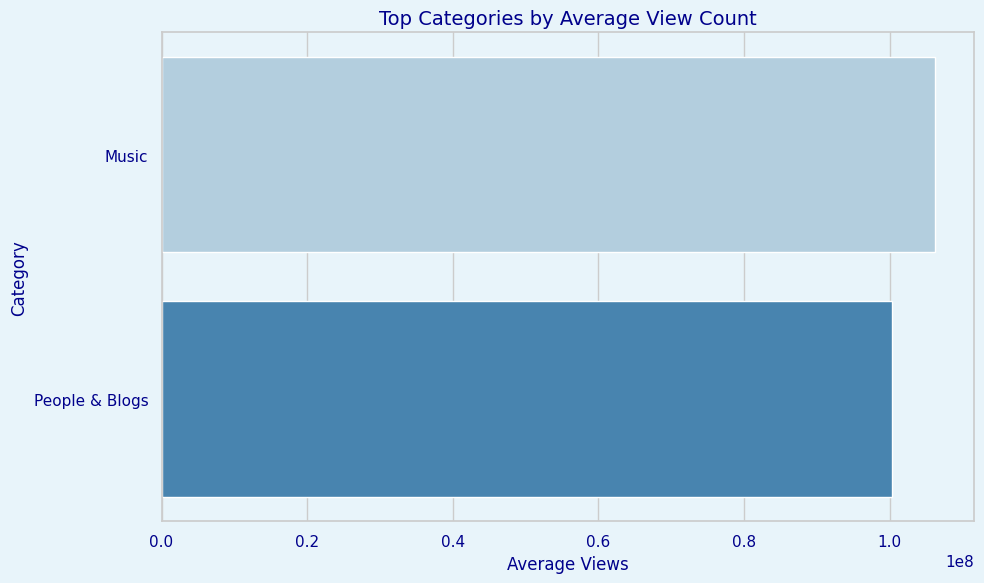

In [17]:
category_views = df.groupby('categories')['view_count'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=category_views.values, y=category_views.index, palette='Blues')
plt.title("Top Categories by Average View Count", fontsize=14, color='darkblue')
plt.xlabel("Average Views")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

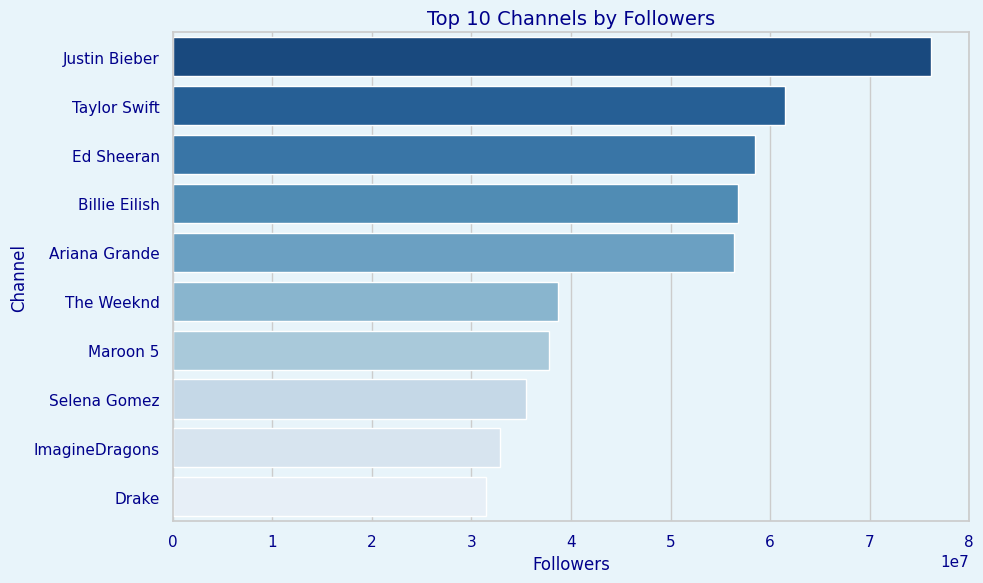

In [18]:
top_channels = df[['channel', 'channel_follower_count']].dropna().drop_duplicates().nlargest(10, 'channel_follower_count')
plt.figure(figsize=(10,6))
sns.barplot(x='channel_follower_count', y='channel', data=top_channels, palette='Blues_r')
plt.title("Top 10 Channels by Followers", fontsize=14, color='darkblue')
plt.xlabel("Followers")
plt.ylabel("Channel")
plt.tight_layout()
plt.show()

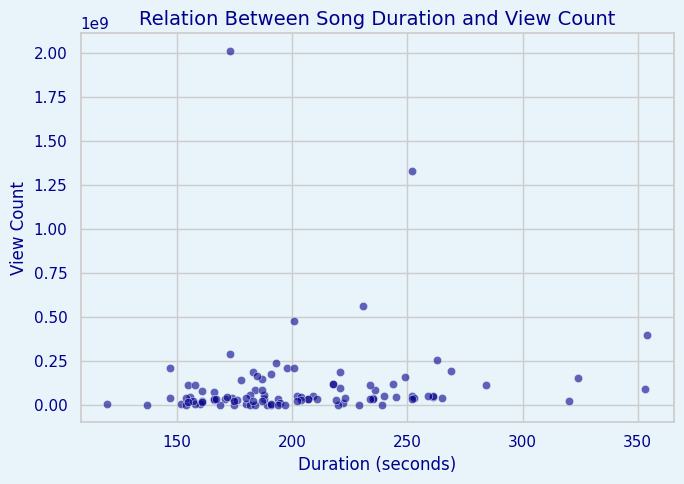

In [19]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='duration', y='view_count', data=df, color='darkblue', alpha=0.6)
plt.title("Relation Between Song Duration and View Count", fontsize=14, color='darkblue')
plt.xlabel("Duration (seconds)")
plt.ylabel("View Count")
plt.tight_layout()
plt.show()

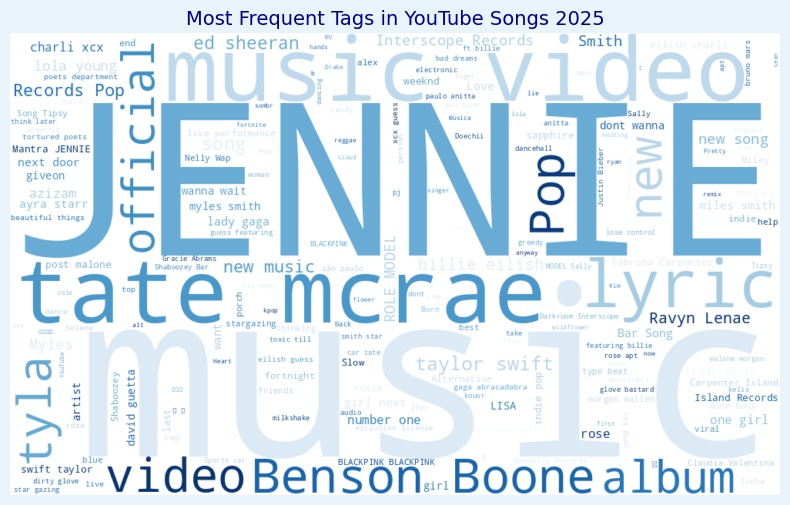

In [20]:
tags_text = ' '.join(df['tags'].dropna().astype(str))
wordcloud = WordCloud(width=1000, height=600, background_color='white', colormap='Blues').generate(tags_text)
plt.figure(figsize=(10,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Frequent Tags in YouTube Songs 2025", fontsize=14, color='darkblue')
plt.show()

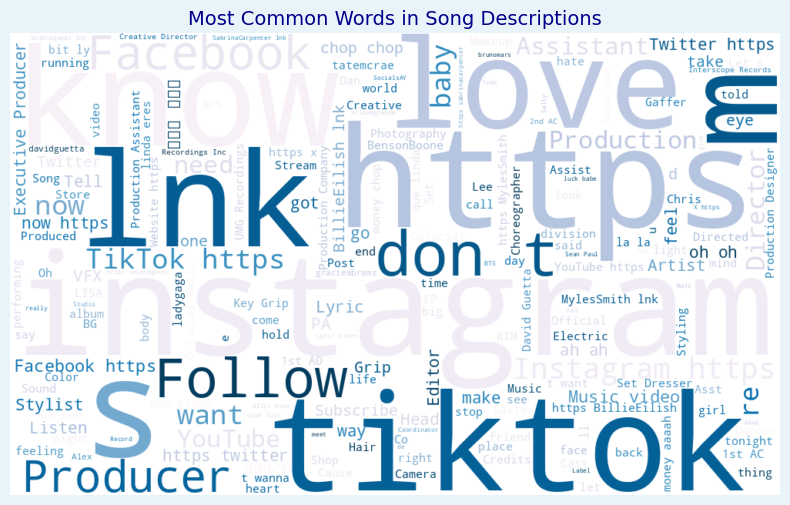

In [21]:
desc_text = ' '.join(df['description'].dropna().astype(str))
wordcloud_desc = WordCloud(width=1000, height=600, background_color='white', colormap='PuBu').generate(desc_text)
plt.figure(figsize=(10,6))
plt.imshow(wordcloud_desc, interpolation='bilinear')
plt.axis('off')
plt.title("Most Common Words in Song Descriptions", fontsize=14, color='darkblue')
plt.show()

## Ml Algorithms

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

In [23]:
print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (100, 13)
                                               title  \
0   ROSÉ & Bruno Mars - APT. (Official Music Video)   
1  Lady Gaga, Bruno Mars - Die With A Smile (Offi...   
2  Reneé Rapp - Leave Me Alone (Official Music Vi...   
3  Billie Eilish - BIRDS OF A FEATHER (Official M...   
4            Reneé Rapp - Mad (Official Music Video)   

                                           fulltitle  \
0   ROSÉ & Bruno Mars - APT. (Official Music Video)   
1  Lady Gaga, Bruno Mars - Die With A Smile (Offi...   
2  Reneé Rapp - Leave Me Alone (Official Music Vi...   
3  Billie Eilish - BIRDS OF A FEATHER (Official M...   
4            Reneé Rapp - Mad (Official Music Video)   

                                         description  view_count categories  \
0  ROSÉ & Bruno Mars - APT.\nDownload/stream: ht...  2009014557      Music   
1  MAYHEM OUT NOW\nhttp://ladygaga.com \n \nListe...  1324833300      Music   
2  Listen to “BITE ME”, the new album from Reneé ...     2536628

In [24]:
df = df.fillna('Unknown')

In [25]:
le = LabelEncoder()
categorical_cols = ['title', 'fulltitle', 'description', 'categories', 'tags', 
                    'duration_string', 'live_status', 'thumbnail', 'channel', 'channel_url']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [26]:
X = df.drop(['categories'], axis=1)
y = df['categories']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Gradient Boosting": GradientBoostingClassifier()
}

In [29]:
accuracy_scores = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds) * 100
    accuracy_scores[name] = acc
    print(f"{name} Accuracy: {acc:.2f}%")

Logistic Regression Accuracy: 90.00%
Decision Tree Accuracy: 90.00%
Random Forest Accuracy: 90.00%
Naive Bayes Accuracy: 90.00%
KNN Accuracy: 90.00%
SVM Accuracy: 90.00%
Gradient Boosting Accuracy: 90.00%


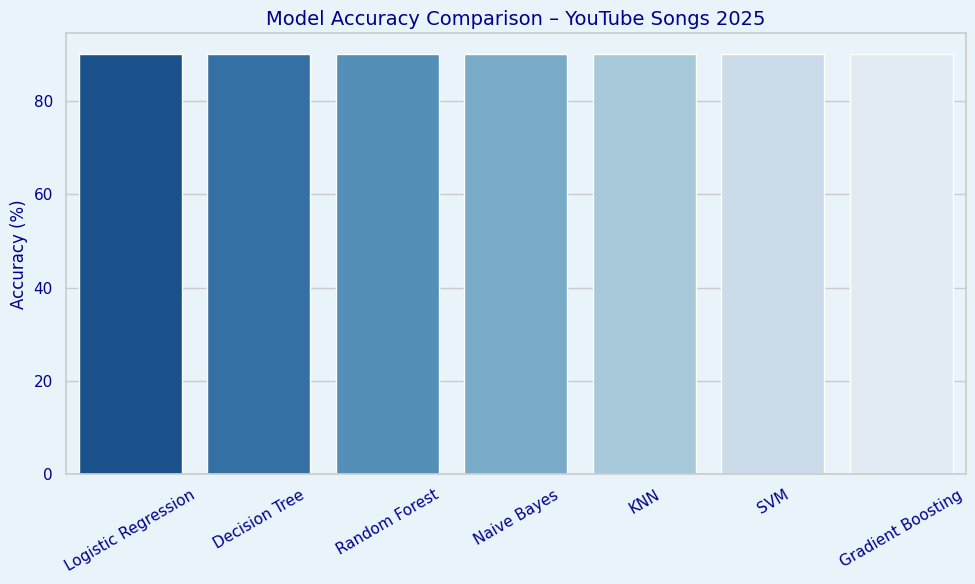

In [30]:
plt.figure(figsize=(10,6))
sns.barplot(x=list(accuracy_scores.keys()), y=list(accuracy_scores.values()), palette="Blues_r")
plt.title("Model Accuracy Comparison – YouTube Songs 2025", fontsize=14, color='darkblue')
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [31]:
best_model = max(accuracy_scores, key=accuracy_scores.get)
print(f"\n✅ Best Performing Model: {best_model} with Accuracy = {accuracy_scores[best_model]:.2f}%")


✅ Best Performing Model: Logistic Regression with Accuracy = 90.00%


## Thank you...pld upvote!!!